# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [4]:
# TODO
print("Số dòng:", df.shape[0], "| Số cột:", df.shape[1])
print()
df.info()

Số dòng: 1338 | Số cột: 7

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## A.2. Missing values & Duplicate data

In [5]:
# TODO
missing = df.isnull().sum()
if missing.sum()>0 :
   print(missing[missing>0])
else :
    print("không có missing value") 

print("số row lặp là :",df.duplicated().sum())

không có missing value
số row lặp là : 1


## A.3. Invalid values

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
# TODO
print(f"age <=0 : {(df['age']<=0).sum()}")
print(f"children <=0 : {(df['children']<0).sum()}")


age <=0 : 0
children <=0 : 0


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [12]:
# TODO
bmi_gr = []
for i in df['bmi'] :
    if i <25 :
        bmi_gr.append("<25")
    elif i <30:
        bmi_gr.append("25-30")
    else:
            bmi_gr.append(">=30")

df['bmi_group'] = bmi_gr
df

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,25-30
1,18,male,33.770,1,no,southeast,1725.55230,>=30
2,28,male,33.000,3,no,southeast,4449.46200,>=30
3,33,male,22.705,0,no,northwest,21984.47061,<25
4,32,male,28.880,0,no,northwest,3866.85520,25-30
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,>=30
1334,18,female,31.920,0,no,northeast,2205.98080,>=30
1335,18,female,36.850,0,no,southeast,1629.83350,>=30
1336,21,female,25.800,0,no,southwest,2007.94500,25-30


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [13]:
for col in ['charges', 'age', 'bmi']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")

print()
print("Mode smoker:", df['smoker'].mode()[0])
print("Mode region:", df['region'].mode()[0])

charges: Mean=13270.42, Median=9382.03, Mode=1639.56
age: Mean=39.21, Median=39.00, Mode=18.00
bmi: Mean=30.66, Median=30.40, Mode=32.30

Mode smoker: no
Mode region: southeast


## Group 2 — Dispersion

In [14]:
for col in ['charges', 'age', 'bmi']:
    s = df[col]
    range_ = s.max() - s.min()
    variance_ = s.var()
    std_ = s.std()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    cv = std_ / s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Variance={variance_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- charges ---
Range=62648.55, Variance=146652372.15, Std=12110.01, IQR=11899.63, CV=0.91
--- age ---
Range=46.00, Variance=197.40, Std=14.05, IQR=24.00, CV=0.36
--- bmi ---
Range=37.17, Variance=37.19, Std=6.10, IQR=8.40, CV=0.20


## Group 3 — Location and Shape

--- age ---
P25=27.00, P50=39.00, P75=51.00
Skewness=0.06, Kurtosis=-1.24
--- bmi ---
P25=26.30, P50=30.40, P75=34.69
Skewness=0.28, Kurtosis=-0.06
--- charges ---
P25=4740.29, P50=9382.03, P75=16639.91
Skewness=1.51, Kurtosis=1.60


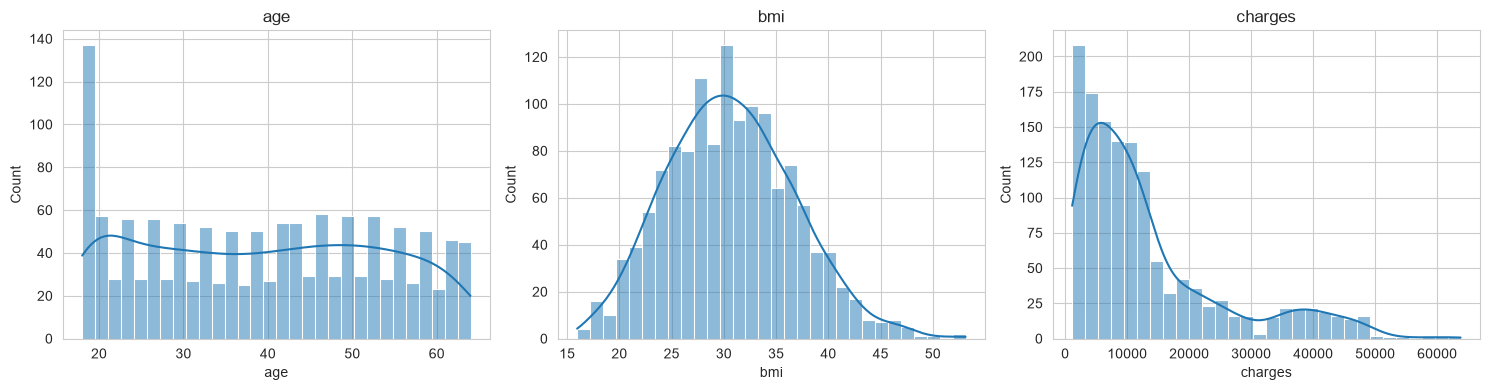

Nhận xét: charges lệch phải rõ rệt, cho thấy một nhóm nhỏ có chi phí rất cao; age và bmi tập trung hơn quanh giá trị trung tâm.


In [15]:
for col in ['age', 'bmi', 'charges']:
    s = df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.50):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['age', 'bmi', 'charges']):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Nhận xét: charges lệch phải rõ rệt, cho thấy một nhóm nhỏ có chi phí rất cao; age và bmi tập trung hơn quanh giá trị trung tâm.")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

            mean    median  count  mean_ratio_vs_non_smoker
smoker                                                     
no       8434.27   7345.41   1064                       1.0
yes     32050.23  34456.35    274                       3.8

Tỷ lệ chi phí smoker / non-smoker theo vùng:
smoker          no       yes  smoker_ratio
region                                    
northeast  9165.53  29673.54          3.24
northwest  8556.46  30192.00          3.53
southeast  8032.22  34845.00          4.34
southwest  8019.28  32269.06          4.02


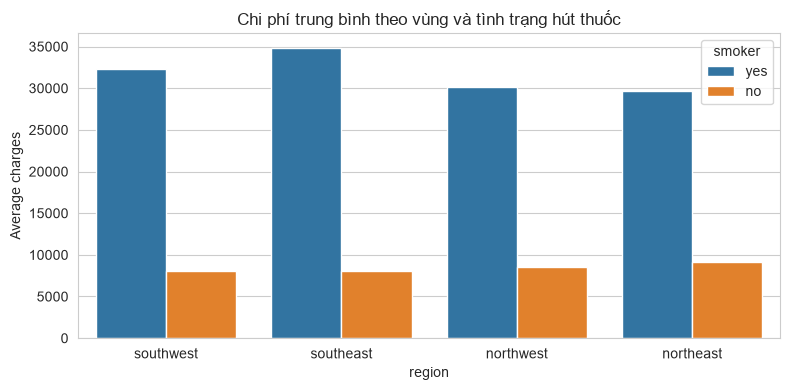


Insight: Người hút thuốc có chi phí trung bình cao hơn 3.8 lần người không hút.
Khoảng cách tương đối lớn nhất ở vùng southeast, nhỏ nhất ở vùng northeast.


In [16]:
charges_by_smoker = df.groupby('smoker')['charges'].agg(['mean', 'median', 'count'])
charges_by_smoker['mean_ratio_vs_non_smoker'] = charges_by_smoker['mean'] / charges_by_smoker.loc['no', 'mean']
print(charges_by_smoker.round(2))

region_smoker = df.pivot_table(index='region', columns='smoker', values='charges', aggfunc='mean')
region_smoker['smoker_ratio'] = region_smoker['yes'] / region_smoker['no']
print("\nTỷ lệ chi phí smoker / non-smoker theo vùng:")
print(region_smoker.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='region', y='charges', hue='smoker', estimator='mean', errorbar=None, ax=ax)
ax.set_title('Chi phí trung bình theo vùng và tình trạng hút thuốc')
ax.set_ylabel('Average charges')
plt.tight_layout()
plt.show()

highest_region = region_smoker['smoker_ratio'].idxmax()
lowest_region = region_smoker['smoker_ratio'].idxmin()
print(f"\nInsight: Người hút thuốc có chi phí trung bình cao hơn {charges_by_smoker.loc['yes', 'mean_ratio_vs_non_smoker']:.1f} lần người không hút.")
print(f"Khoảng cách tương đối lớn nhất ở vùng {highest_region}, nhỏ nhất ở vùng {lowest_region}.")

## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

               mean    median  count
region                              
southeast  14735.41   9294.13    364
northeast  13406.38  10057.65    324
northwest  12417.58   8965.80    325
southwest  12346.94   8798.59    325


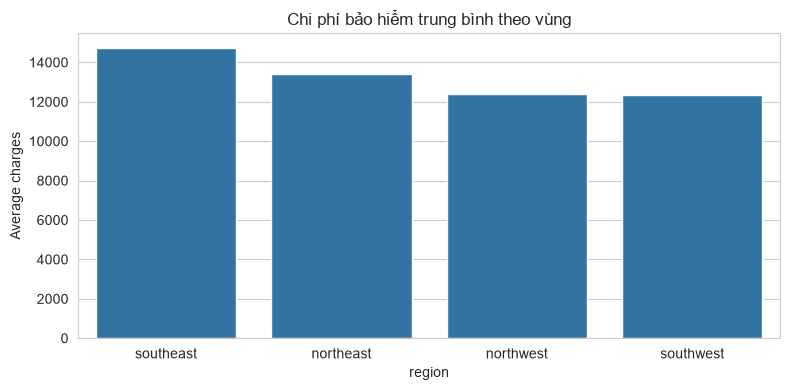

Insight: Vùng có chi phí bảo hiểm trung bình cao nhất là southeast (14735.41).


In [18]:
charges_by_region = df.groupby('region')['charges'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print(charges_by_region.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='region', y='charges', estimator='mean', errorbar=None, order=charges_by_region.index, ax=ax)
ax.set_title('Chi phí bảo hiểm trung bình theo vùng')
ax.set_ylabel('Average charges')
plt.tight_layout()
plt.show()

print(f"Insight: Vùng có chi phí bảo hiểm trung bình cao nhất là {charges_by_region.index[0]} ({charges_by_region.iloc[0]['mean']:.2f}).")

## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

              mean    median  count
children                           
0         12365.98   9856.95    574
1         12731.17   8483.87    324
2         15073.56   9264.98    240
3         15355.32  10600.55    157
4         13850.66  11033.66     25
5          8786.04   8589.57     18

Tương quan Pearson giữa children và charges: 0.068


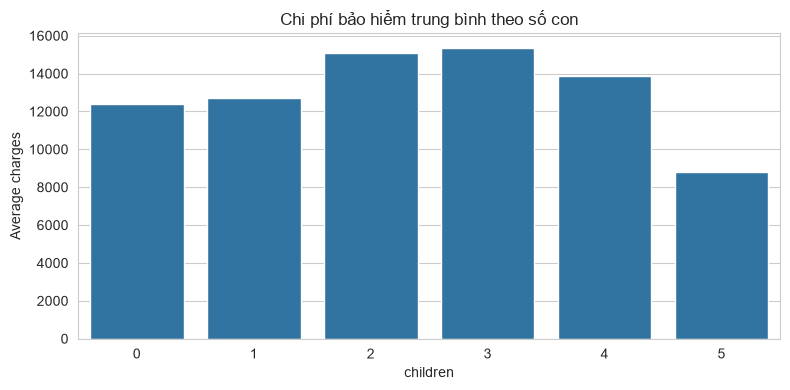

Insight: Số con có liên hệ dương nhưng yếu với chi phí; mức trung bình không tăng đều theo từng giá trị children.


In [19]:
charges_by_children = df.groupby('children')['charges'].agg(['mean', 'median', 'count'])
print(charges_by_children.round(2))

children_corr = df['children'].corr(df['charges'])
print(f"\nTương quan Pearson giữa children và charges: {children_corr:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='children', y='charges', estimator='mean', errorbar=None, ax=ax)
ax.set_title('Chi phí bảo hiểm trung bình theo số con')
ax.set_ylabel('Average charges')
plt.tight_layout()
plt.show()

print("Insight: Số con có liên hệ dương nhưng yếu với chi phí; mức trung bình không tăng đều theo từng giá trị children.")

## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.